# MAE6292 - Homework \# 3

Calibration with DLT and 3D scene construction

## Import Modules



In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as linalg
import cv2

## Jupyter Notebook / VSCode

It turns out that `cv2.imshow()` does not work in Jupter Notebook as well. You may use the follwing function `cv2_imshow` instead. 

Also, we are importing tools developed in class as `mae6292` module.

In [12]:
from mae6292.imshow import cv2_imshow
import mae6292.tools as mae6292

## Getting Data From HW#2

In HW#2, we made a virtual cube on the photo image as follows.

![](./img_cube.png)

First, we have to load several variables from HW#2. 

1. Append your HW2 with the following code to create a data file, `HW2.npz` that containts the listed variables. 

`np.savez('HW2.npz', P = vertices, p = M@vertices, K_cv = K, R_cv = R, T_cv = T, M_cv=M)`

2. Copy the data file `HW2.npz` to the current folder of HW3.

3. Excute the following code to load variables from the data file. 

In [13]:
np.set_printoptions(precision=5)

with np.load('HW2.npz') as data:
    P = data['P']
    p = data['p']
    K_cv = data['K_cv']
    R_cv = data['R_cv']
    T_cv = data['T_cv']
    M_cv = data['M_cv']
    
print('K_cv = ',K_cv)
print('R_cv = ',R_cv)
print('T_cv = ',T_cv)
print('M_cv = ',M_cv)

K_cv =  [[4.48368e+03 0.00000e+00 2.85551e+03]
 [0.00000e+00 4.76083e+03 1.99085e+03]
 [0.00000e+00 0.00000e+00 1.00000e+00]]
R_cv =  [[ 0.99893  0.03923 -0.02447]
 [-0.00563  0.62845  0.77783]
 [ 0.04589 -0.77686  0.628  ]]
T_cv =  [[-2.49735]
 [-0.6857 ]
 [10.02676]]
M_cv =  [[ 4.60991e+03 -2.04246e+03  1.68355e+03  1.74342e+04]
 [ 6.45714e+01  1.44532e+03  4.95337e+03  1.66973e+04]
 [ 4.58869e-02 -7.76861e-01  6.27997e-01  1.00268e+01]]


## Problem 1 (DLT)

In this part, 

1. Using `K, R, T, M = mae6292.calibrateCamera_Tsai(p, P)` calibrate the camera according to Tsai's method.

2. Print `K, R, T, M` and make it sure that they are consistent with the above values computed by OpenCV.

3. Using [scipy.linalg.norm()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.norm.html), compute $\|K-K_{cv}\|$, $\|R-R_{cv}\|$, $\|T-T_{cv}\|$, and $\|M-M_{cv}\|$, and print.


In [14]:
# 1. compute K, R, T, M
K, R, T, M = mae6292.calibrateCamera_Tsai(p, P)

# 2. print K, R, T, M

print('K = ',K)
print('R = ',R)
print('T = ',T)
print('M = ',M)

# 3. compute and print errors
K_error = linalg.norm(K - K_cv)
R_error = linalg.norm(R - R_cv)
T_error = linalg.norm(T - T_cv)
M_error = linalg.norm(M - M_cv)

print("Errors:")
print(f"||K - K_cv|| = {K_error}")
print(f"||R - R_cv|| = {R_error}")
print(f"||T - T_cv|| = {T_error}")
print(f"||M - M_cv|| = {M_error}")


K =  [[ 4.48368e+03 -2.18406e-09  2.85551e+03]
 [ 0.00000e+00  4.76083e+03  1.99085e+03]
 [ 0.00000e+00  0.00000e+00  1.00000e+00]]
R =  [[ 0.99893  0.03923 -0.02447]
 [-0.00563  0.62845  0.77783]
 [ 0.04589 -0.77686  0.628  ]]
T =  [[-2.49735]
 [-0.6857 ]
 [10.02676]]
M =  [[ 4.60991e+03 -2.04246e+03  1.68355e+03  1.74342e+04]
 [ 6.45714e+01  1.44532e+03  4.95337e+03  1.66973e+04]
 [ 4.58869e-02 -7.76861e-01  6.27997e-01  1.00268e+01]]
Errors:
||K - K_cv|| = 3.0879717176864756e-08
||R - R_cv|| = 9.829800003267141e-12
||T - T_cv|| = 6.945878629228017e-11
||M - M_cv|| = 6.061810284607362e-08


## Problem 2 (3D Scene Construction)

1. The following codes generate a wireframe camera at the pose `(R,T)` defined above. You may need to adjust the axis limits at the following lines. 

```
ax.axes.set_xlim3d(left=-2, right=10)
ax.axes.set_ylim3d(bottom=-2, top=6) 
ax.axes.set_zlim3d(bottom=0, top=-6)
```

2. Using the following command generate the checker board 

```
cb = mae6292.ChessBoard( (CHECKER_ROW, CHECKER_COL), (x of upper-left corner, y of upper left corner) )``
cb.draw(ax)
```

See the example in [https://github.com/GW-MAE6292/python_examples/tree/main/DLT](https://github.com/GW-MAE6292/python_examples/tree/main/DLT)

3. In the above, the homogeneous coordinates of the vertices of the cube in the world frame are stored in the 4 by 8 np.array `P`. Convert it into the 3 by 8 np.array `P_W` of the world coordinates.


4. Read [3D line plot in python](https://medium.com/@rohitadnaik/3d-line-plot-in-python-2fbeca99b9ba). 

For example, the following command generate a line from $(0,0,0)$ to $(0,0,-1)$.

```
ax.plot([0, 0], [0, 0], [0, -1],'r',linewidth=1)
```
Draw a 3D wire-frame cube using `P_W` and the above command.

5. Save the image as `prob2.png` using

```
plt.savefig('prob2.png')
```

The end results should be similar as

![](./prob2_example.png)

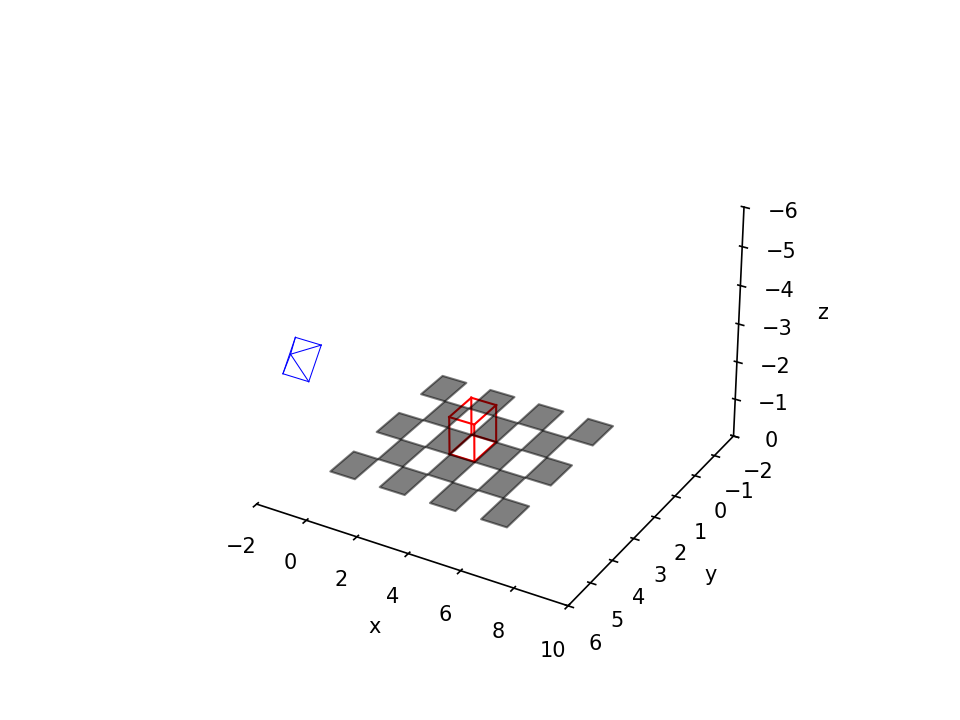

In [15]:
# uncomment the following line for interactive view of the image
# %matplotlib ipympl
%matplotlib widget

# 1. draw wire-frame camera
camera = mae6292.WireFrameCamera()
fig, ax = camera.draw(R,T)
ax.axis('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('w')
ax.yaxis.pane.set_edgecolor('w')
ax.zaxis.pane.set_edgecolor('w')
ax.grid(False)

# Change the axis limit if needed
ax.axes.set_xlim3d(left=-2, right=10)
ax.axes.set_ylim3d(bottom=6, top=-2) 
ax.axes.set_zlim3d(bottom=0, top=-6) 

# 2. draw chess board
# cb = mae6292.ChessBoard((CHECKER_ROW, CHECKER_COL),(x of upper-left corner, y of upper left corner))
cb = mae6292.ChessBoard((6, 4), (-1, -1))
cb.draw(ax)

# 3. convert the homogeneous coordinates P into P_W
P_W = P[0:3,:]

# 4. draw wire cube
# Loop through the first 4 vertices (bottom face)
for i in range(4):
    for j in [0, 4]:  # j=0 for bottom face, j=4 for top face
        # Connect face edges (bottom and top)
        ax.plot([P_W[0, i + j], P_W[0, (i + 1) % 4 + j]], 
                [P_W[1, i + j], P_W[1, (i + 1) % 4 + j]], 
                [P_W[2, i + j], P_W[2, (i + 1) % 4 + j]], 'r', linewidth=1)

    # Connect vertical edges between bottom and top faces
    ax.plot([P_W[0, i], P_W[0, i + 4]], 
            [P_W[1, i], P_W[1, i + 4]], 
            [P_W[2, i], P_W[2, i + 4]], 'r', linewidth=1)

# 5. save
plt.savefig('prob2.png')

## How to Turn in

Make it sure you add the following files to the repository before pusing it back to github.
1. prob2.png
